data_split = {"Train": {"Years": 10,"Period": "2004–2015"},
              "Validation": {"Years": 4,"Period": "2016–2019"},
              "Test": {"Years": 4,"Period": "2025"}}

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from functions.Data_download import get_dataset_split, filter_volume_lowprices_availtickers

pd.set_option('display.max_columns', 100) 
pd.set_option('display.max_colwidth', 100) 
pd.set_option('display.width', 1000)

df_prices = get_dataset_split(split="test")

df_prices = df_prices.sort_values(by=["ticker", "date"]).reset_index(drop=True)

cols = ["ticker"] + [col for col in df_prices.columns if col != "ticker"]
df_prices = df_prices[cols]
df_prices['date'] = df_prices['date'].dt.tz_localize(None) # drop timezone

# Filtering and getting available tickers
df_prices, tickers = filter_volume_lowprices_availtickers(df_prices, volume_threshold=800000, remove_price_below=7, volume_window=20)
df_prices

Duplicates removed. New shape: (3129727, 8)
Number of tickers after time-aware filters: 2110
Number of tickers after ticker-sector pairs filter: 1349


,ticker,date,close,open,high,low,adjusted_close,volume,avg_volume,volume_flag,price_flag,cutoff_date
0,A,2020-01-02,85.95,85.90,86.350,85.200,82.7142,1410500,NaN,False,False,NaT
1,A,2020-01-03,84.57,84.67,85.330,84.500,81.3861,1118300,1.410500e+06,False,False,NaT
2,A,2020-01-06,84.82,84.00,84.820,83.600,81.6267,1993200,1.264400e+06,False,False,NaT
3,A,2020-01-07,85.08,83.96,85.260,83.940,81.8769,1684700,1.507333e+06,False,False,NaT
4,A,2020-01-08,85.92,85.96,86.470,85.200,82.6853,1847600,1.551675e+06,False,False,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...
3126964,ZVIA,2021-08-03,13.83,13.65,13.945,13.522,13.8300,194200,9.225125e+05,False,False,2021-08-05
3126965,ZVIA,2021-08-04,14.02,13.78,14.170,13.618,14.0200,158300,8.415889e+05,False,False,2021-08-05
3128146,ZWS,2020-01-02,32.84,32.91,32.980,32.530,31.5131,809900,NaN,False,False,2020-01-07
3128147,ZWS,2020-01-03,32.81,32.33,32.860,32.210,31.4843,830900,8.099000e+05,False,False,2020-01-07


In [2]:
df_prices['date'].max()

Timestamp('2026-04-17 00:00:00')

In [3]:
"""fundamental_factors = [ 'bm', 'capei', 'evm', 'pcf',
    'pe_exi', 'pe_inc', 'pe_op_basic', 'pe_op_dil', 'ps', 'ptb', 'gprof', 'aftret_eq', 'aftret_equity', 'aftret_invcapx', 'gpm', 'npm',
    'opmad', 'opmbd', 'ptpm', 'roa', 'roce','roe', 'capital_ratio', 'equity_invcap', 'debt_invcap', 'totdebt_invcap',
    'cash_debt', 'cash_lt', 'cfm','debt_ebitda', 'dltt_be','lt_debt', 'lt_ppent', 'de_ratio',
    'debt_assets', 'debt_at', 'debt_capital', 'at_turn','pay_turn', 'rect_turn','sale_invcap','accrual', 'rd_sale', 'adv_sale', 'staff_sale']"""

"""fundamental_factors = [
    'bm',                   # 0.0179
    'at_turn',              # 0.0071 (borderline but positive)
    'pay_turn',             # 0.0093
    'sale_invcap',          # 0.0087
    'cash_lt',              # 0.0056
    'rect_turn',            # 0.0047
    'rd_sale',
    'gprof', 'roe'              # 0.0031
]

#factors = pd.read_csv("datasets/compustat_factors.csv", parse_dates=["public_date"], usecols=['ticker', 'public_date', 'bm', 'gprof', 'roe'])
factors = pd.read_csv("datasets/compustat_factors.csv", parse_dates=["public_date"], usecols=['ticker', 'public_date']+fundamental_factors)
factors = factors[factors['public_date'].isin(df_prices['date'].unique())]

merged = pd.merge(df_prices,factors,how='left',left_on=['ticker', 'date'],right_on=['ticker', 'public_date']).drop(columns=['public_date'])
merged = merged.sort_values(['ticker', 'date'])

# Separate keys and numeric data
non_numeric = merged[['ticker', 'date']]
numeric = merged.drop(columns=['ticker', 'date'])
# Forward fill numeric fundamentals grouped by ticker
numeric_filled = numeric.groupby(non_numeric['ticker']).ffill()
merged = pd.concat([non_numeric, numeric_filled], axis=1)
merged = merged.dropna(subset=fundamental_factors)"""

'fundamental_factors = [\n    \'bm\',                   # 0.0179\n    \'at_turn\',              # 0.0071 (borderline but positive)\n    \'pay_turn\',             # 0.0093\n    \'sale_invcap\',          # 0.0087\n    \'cash_lt\',              # 0.0056\n    \'rect_turn\',            # 0.0047\n    \'rd_sale\',\n    \'gprof\', \'roe\'              # 0.0031\n]\n\n#factors = pd.read_csv("datasets/compustat_factors.csv", parse_dates=["public_date"], usecols=[\'ticker\', \'public_date\', \'bm\', \'gprof\', \'roe\'])\nfactors = pd.read_csv("datasets/compustat_factors.csv", parse_dates=["public_date"], usecols=[\'ticker\', \'public_date\']+fundamental_factors)\nfactors = factors[factors[\'public_date\'].isin(df_prices[\'date\'].unique())]\n\nmerged = pd.merge(df_prices,factors,how=\'left\',left_on=[\'ticker\', \'date\'],right_on=[\'ticker\', \'public_date\']).drop(columns=[\'public_date\'])\nmerged = merged.sort_values([\'ticker\', \'date\'])\n\n# Separate keys and numeric data\nnon_numeric = me

In [4]:
rolling_df = df_prices.copy()
tickers = pd.read_csv('datasets/tickers.csv')

# add sector to rolling_df
ticker_to_sector = tickers.set_index('ticker')['gsector'].to_dict()
rolling_df['gsector'] = rolling_df['ticker'].map(ticker_to_sector)
rolling_df.head()

,ticker,date,close,open,high,low,adjusted_close,volume,avg_volume,volume_flag,price_flag,cutoff_date,gsector
0,A,2020-01-02,85.95,85.90,86.35,85.20,82.7142,1410500,NaN,False,False,NaT,35.0
1,A,2020-01-03,84.57,84.67,85.33,84.50,81.3861,1118300,1.410500e+06,False,False,NaT,35.0
2,A,2020-01-06,84.82,84.00,84.82,83.60,81.6267,1993200,1.264400e+06,False,False,NaT,35.0
3,A,2020-01-07,85.08,83.96,85.26,83.94,81.8769,1684700,1.507333e+06,False,False,NaT,35.0
4,A,2020-01-08,85.92,85.96,86.47,85.20,82.6853,1847600,1.551675e+06,False,False,NaT,35.0


In [5]:
from functions.Tech_Indicators import rsi, macd, rolling_beta, ulcer_index, atr
rolling_df = rolling_df.sort_values(['ticker', 'date'])

# Returns
rolling_df['daily_return'] = rolling_df.groupby('ticker')['adjusted_close'].pct_change()
rolling_df['daily_return'] = rolling_df['daily_return'].clip(-0.3, 0.3)
rolling_df['weekly_return_5d'] = rolling_df.groupby('ticker')['adjusted_close'].pct_change(5)
rolling_df['medium_return_20d'] = rolling_df.groupby('ticker')['adjusted_close'].pct_change(20)
# Volatility 
rolling_df['volatility_20d'] = rolling_df.groupby('ticker')['daily_return'].rolling(20).std().reset_index(0,drop=True)
# Volume
rolling_df['avg_volume_20d'] = rolling_df.groupby('ticker')['volume'].rolling(20).mean().reset_index(0,drop=True)
rolling_df['momentum_volatility'] = rolling_df.groupby('ticker')['weekly_return_5d'].rolling(20).std().reset_index(0,drop=True)
rolling_df['macd_hist'] = rolling_df.groupby('ticker')['adjusted_close'].transform(macd)
# Sector beta
rolling_df['sector_return'] = rolling_df.groupby(['gsector', 'date'])['medium_return_20d'].transform('mean')
group = rolling_df.groupby('ticker', group_keys=False)
beta_values = group[['medium_return_20d', 'sector_return']].apply(lambda df: rolling_beta(df['medium_return_20d'], df['sector_return'], window=60))
rolling_df['beta_sector'] = beta_values
# Range compression
rolling_df['range_compression'] = (rolling_df['high'] - rolling_df['low']) / rolling_df['close']
rolling_df['range_compression_5d'] = rolling_df.groupby('ticker')['range_compression'].rolling(5).mean().reset_index(0, drop=True)
# Ulcer
rolling_df['ulcer_20d'] = rolling_df.groupby('ticker')['adjusted_close'].transform(lambda x: ulcer_index(x, 20))
# kc_width
atr_input = rolling_df[['ticker', 'high', 'low', 'close']].copy()
rolling_df['atr_20d'] = ( atr_input.groupby('ticker', group_keys=False).apply(lambda df: atr(df['high'], df['low'], df['close'], n=20), include_groups=False))
rolling_df['kc_width'] = rolling_df['atr_20d'] / rolling_df['close']

# exponential smoothing
window_span = 50  # ~10 weeks
factor_cols = ['weekly_return_5d','volatility_20d','avg_volume_20d', 'momentum_volatility', 'macd_hist', 'beta_sector', 'range_compression_5d'] #+ fundamental_factors

for col in factor_cols:
    rolling_df[col] = rolling_df.groupby('ticker')[col].transform(lambda x: x.ewm(span=window_span, min_periods=1).mean())

rolling_df

,ticker,date,close,open,high,low,adjusted_close,volume,avg_volume,volume_flag,price_flag,cutoff_date,gsector,daily_return,weekly_return_5d,medium_return_20d,volatility_20d,avg_volume_20d,momentum_volatility,macd_hist,sector_return,beta_sector,range_compression,range_compression_5d,ulcer_20d,atr_20d,kc_width
0,A,2020-01-02,85.95,85.90,86.350,85.200,82.7142,1410500,NaN,False,False,NaT,35.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.013380,NaN,NaN,NaN,NaN
1,A,2020-01-03,84.57,84.67,85.330,84.500,81.3861,1118300,1.410500e+06,False,False,NaT,35.0,-0.016056,NaN,NaN,NaN,NaN,NaN,-0.043226,NaN,NaN,0.009814,NaN,NaN,NaN,NaN
2,A,2020-01-06,84.82,84.00,84.820,83.600,81.6267,1993200,1.264400e+06,False,False,NaT,35.0,0.002956,NaN,NaN,NaN,NaN,NaN,-0.069115,NaN,NaN,0.014383,NaN,NaN,NaN,NaN
3,A,2020-01-07,85.08,83.96,85.260,83.940,81.8769,1684700,1.507333e+06,False,False,NaT,35.0,0.003065,NaN,NaN,NaN,NaN,NaN,-0.081562,NaN,NaN,0.015515,NaN,NaN,NaN,NaN
4,A,2020-01-08,85.92,85.96,86.470,85.200,82.6853,1847600,1.551675e+06,False,False,NaT,35.0,0.009873,NaN,NaN,NaN,NaN,NaN,-0.076139,NaN,NaN,0.014781,0.013575,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3126964,ZVIA,2021-08-03,13.83,13.65,13.945,13.522,13.8300,194200,9.225125e+05,False,False,2021-08-05,30.0,0.014674,-0.000368,NaN,NaN,NaN,NaN,-0.018342,0.011185,NaN,0.030586,0.064529,NaN,NaN,NaN
3126965,ZVIA,2021-08-04,14.02,13.78,14.170,13.618,14.0200,158300,8.415889e+05,False,False,2021-08-05,30.0,0.013738,0.016504,NaN,NaN,NaN,NaN,-0.011533,-0.008491,NaN,0.039372,0.060150,NaN,NaN,NaN
3128146,ZWS,2020-01-02,32.84,32.91,32.980,32.530,31.5131,809900,NaN,False,False,2020-01-07,20.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.013703,NaN,NaN,NaN,NaN
3128147,ZWS,2020-01-03,32.81,32.33,32.860,32.210,31.4843,830900,8.099000e+05,False,False,2020-01-07,20.0,-0.000914,NaN,NaN,NaN,NaN,NaN,-0.000937,NaN,NaN,0.019811,NaN,NaN,NaN,NaN


weak regime 2024-08-13 00:00:00 0.5
weak regime 2025-02-05 00:00:00 0.5
weak regime 2026-01-20 00:00:00 0.5
weak regime 2026-04-16 00:00:00 0.5
Implement new portfolio on the trading day after: 2026-04-16 00:00:00 
   ticker  weight_old  weight_new  weight_change
0    CAT    0.000000    0.166667       0.166667
1   DINO    0.000000    0.166667       0.166667
2    DOW    0.333333    0.000000      -0.333333
3    GEV    0.333333    0.000000      -0.333333
4    HUN    0.000000    0.166667       0.166667
5    LNG    0.333333    0.000000      -0.333333


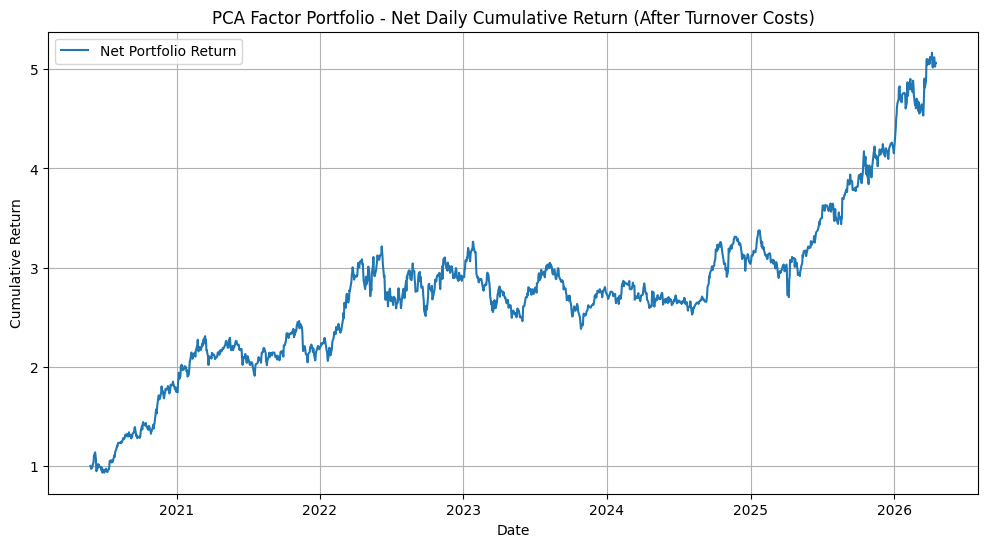

In [6]:
from functions.Residuals_PCA_function import  get_residuals, composite_alpha, generate_long_only_signals, filter_fundamentals, build_daily_net_portfolio_returns
from functions.Residuals_PCA_function import calculate_future_returns, Ledoit_pca_factor_loadings, pca_factor_loadings, neutralize_z_residual
from functions.Residuals_PCA_function import regime_scaling, vol_scaling, calculate_turnover_and_cost, calculate_rebalance_trades, calculate_portfolio_return

rebalance_dates, rolling_df = calculate_future_returns(rolling_df, holding_period_days=20)

portfolio_returns = [{ 'date': rebalance_dates[4], 'portfolio_return': 0, 'raw_return': 0, 'turnover': 0, 'transaction_cost': 0}]
previous_longs_df = pd.DataFrame(columns=['ticker', 'weight'])  # Start empty for first rebalance
signal_history = []
alpha_history = {}  # ticker → smoothed alpha
portfolio_weight_history = []

transaction_cost = 0.004375
n=5
for rebalance_date in rebalance_dates[n:]:

    df_slice = rolling_df[rolling_df['date'] == rebalance_date].copy()
    df_slice = df_slice[(df_slice['ulcer_20d'] < df_slice['ulcer_20d'].quantile(0.6))] #& 
                        #(df_slice['kc_width'] < df_slice['kc_width'].quantile(0.8))]# filter out worst 20% drawdown and volatility risk
    #df_slice = filter_fundamentals(df_slice, drop_bottom=0.2) # filter out companies with low fundamentals

    factor_loadings = pca_factor_loadings(df_slice, factor_cols, pcs_to_use=slice(None))
    residuals_df = get_residuals(factor_loadings, df_slice[['ticker', 'gsector', 'weekly_return_5d']])
    residuals_df = neutralize_z_residual(residuals_df, df_slice, controls = ['beta_sector'])
    residuals_df = composite_alpha(residuals_df, alpha_history)
    
    # Generate longs using smoothed residual
    longs_df = generate_long_only_signals(residuals_df, top_n=3, skip_bottom_n=0, per_sector_limit=1)
    longs_df = longs_df.reset_index(drop=True)

    # Apply regime scaling and volatility scaling
    regime_scale = regime_scaling(residuals_df, rebalance_date, longs_df, signal_history)
    #vol_scale = vol_scaling(portfolio_returns, target_vol = 0.08)
    if regime_scale == 0.5: #or vol_scale<0.5:
        longs_df['weight'] *= 0.5 # reduce exposure during unstable regimes

    # Calculate turnover, trades that need to be executed and portfolio return
    turnover, transaction_cost, _ = calculate_turnover_and_cost(previous_longs_df, longs_df, transaction_cost_per_unit=transaction_cost)
    trades = calculate_rebalance_trades(longs_df, previous_longs_df)

    portfolio_return, _ = calculate_portfolio_return(longs_df, df_slice[['ticker', 'future_return']], rebalance_date)
    net_portfolio_return = portfolio_return - transaction_cost
    portfolio_returns.append({'date': rebalance_date,
                              'portfolio_return': net_portfolio_return,
                              'raw_return': portfolio_return, 
                              'turnover': turnover, 
                              'transaction_cost': transaction_cost})

    # Update previous longs
    previous_longs_df = longs_df.copy()
    # Save weights and rebalance date for forward-filling later
    longs_df['date'] = rebalance_date
    portfolio_weight_history.append(longs_df.copy())

    if rebalance_date == rebalance_dates[-1]: print('Implement new portfolio on the trading day after:',rebalance_date,'\n', trades)


net_result_df = build_daily_net_portfolio_returns(rolling_df,portfolio_weight_history,rebalance_dates, n=n, transaction_cost_per_unit=transaction_cost)

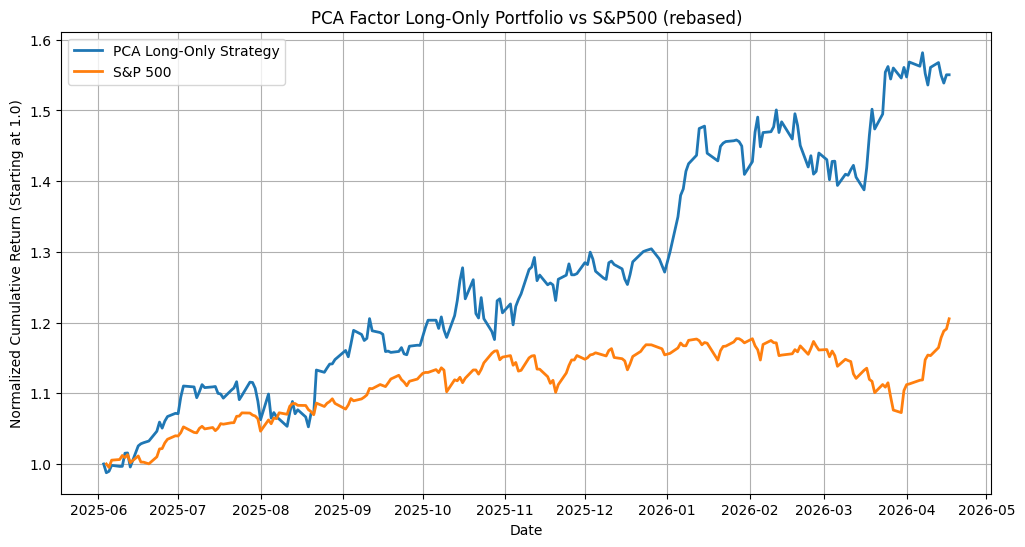

In [7]:
sp500 = pd.read_csv('datasets/sp500_total_return.csv')
sp500['date'] = pd.to_datetime(sp500['date']).dt.tz_localize(None)
sp500 = sp500.sort_values('date')
sp500 = sp500[sp500['date'] >= '2025-06-03']

sp500['return'] = sp500['adjusted_close'].pct_change()
sp500['cumulative_return'] = (1 + sp500['return']).cumprod()

net_result_df['date'] = pd.to_datetime(net_result_df['date']).dt.tz_localize(None)
net_result_df = net_result_df[net_result_df['date'] >= '2025-06-03']

compare_df = pd.DataFrame()
compare_df['date'] = net_result_df['date']
compare_df = compare_df.merge(sp500[['date', 'return', 'cumulative_return']], on='date', how='left')
compare_df['cumulative_return'] = compare_df['cumulative_return'].ffill()
compare_df['pca_cumulative_return'] = net_result_df['cumulative_return'].values

# --- Normalize both to 1 on June 3, 2025 ---
start_sp500 = compare_df.loc[compare_df['date'] >= '2025-06-03', 'cumulative_return'].dropna().iloc[0]
start_pca = compare_df.loc[compare_df['date'] >= '2025-06-03', 'pca_cumulative_return'].dropna().iloc[0]

compare_df['cumulative_return'] /= start_sp500
compare_df['pca_cumulative_return'] /= start_pca

# --- Plot ---
plt.figure(figsize=(12,6))
plt.plot(compare_df['date'], compare_df['pca_cumulative_return'], label='PCA Long-Only Strategy', linewidth=2)
plt.plot(compare_df['date'], compare_df['cumulative_return'], label='S&P 500', linewidth=2)
plt.title("PCA Factor Long-Only Portfolio vs S&P500 (rebased)")
plt.xlabel("Date")
plt.ylabel("Normalized Cumulative Return (Starting at 1.0)")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
compare_df['pca_return'] = compare_df['pca_cumulative_return'].pct_change()
compare_df['sp500_return'] = compare_df['cumulative_return'].pct_change()

returns = compare_df.dropna(subset=['pca_return', 'sp500_return'])

# Annualize Sharpe ratio assuming 252 trading days
annualization_factor = np.sqrt(252)
pca_sharpe = returns['pca_return'].mean() / returns['pca_return'].std() * annualization_factor
sp500_sharpe = returns['sp500_return'].mean() / returns['sp500_return'].std() * annualization_factor

print(f"PCA Strategy Sharpe:  {pca_sharpe:.2f}")
print(f"S&P 500 Sharpe:       {sp500_sharpe:.2f}")


PCA Strategy Sharpe:  2.31
S&P 500 Sharpe:       1.83


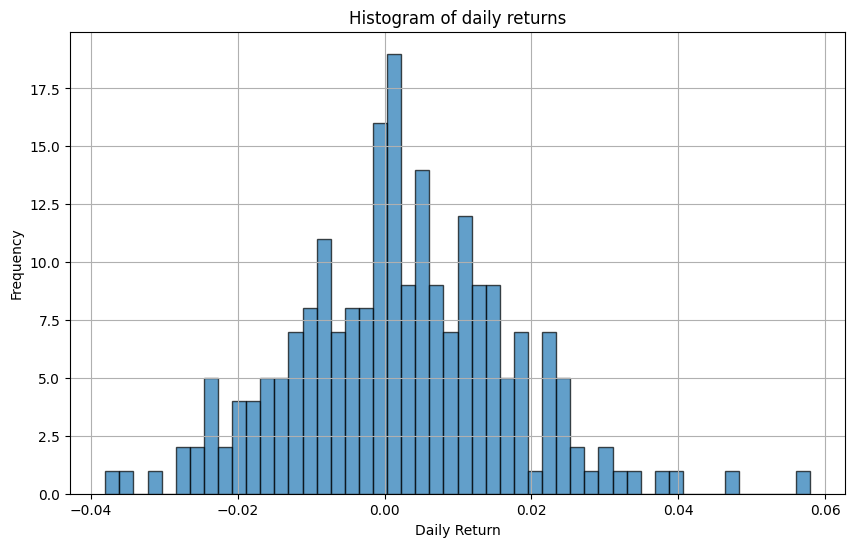

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(net_result_df['net_return'].dropna(), bins=50, edgecolor='k', alpha=0.7)
plt.title('Histogram of daily returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [10]:
from scipy.stats import spearmanr

for factor in factor_cols:
    df = rolling_df[[factor, 'future_return']].dropna()  # Drop NaN rows
    if len(df) > 0:
        ic, _ = spearmanr(df[factor], df['future_return'])
        print(f"IC for {factor}: {ic}")
    else:
        print(f"IC for {factor}: Not enough data")


IC for weekly_return_5d: -0.011306489492022146
IC for volatility_20d: 0.09942101405543088
IC for avg_volume_20d: 0.018081103160337657
IC for momentum_volatility: 0.08618563925708307
IC for macd_hist: 0.00500806130877556
IC for beta_sector: 0.014922074725604983
IC for range_compression_5d: 0.09240806163001017


In [11]:
rebalance_dates

[Timestamp('2020-01-02 00:00:00'),
 Timestamp('2020-01-31 00:00:00'),
 Timestamp('2020-03-02 00:00:00'),
 Timestamp('2020-03-30 00:00:00'),
 Timestamp('2020-04-28 00:00:00'),
 Timestamp('2020-05-27 00:00:00'),
 Timestamp('2020-06-24 00:00:00'),
 Timestamp('2020-07-23 00:00:00'),
 Timestamp('2020-08-20 00:00:00'),
 Timestamp('2020-09-18 00:00:00'),
 Timestamp('2020-10-16 00:00:00'),
 Timestamp('2020-11-13 00:00:00'),
 Timestamp('2020-12-14 00:00:00'),
 Timestamp('2021-01-13 00:00:00'),
 Timestamp('2021-02-11 00:00:00'),
 Timestamp('2021-03-12 00:00:00'),
 Timestamp('2021-04-12 00:00:00'),
 Timestamp('2021-05-10 00:00:00'),
 Timestamp('2021-06-08 00:00:00'),
 Timestamp('2021-07-07 00:00:00'),
 Timestamp('2021-08-04 00:00:00'),
 Timestamp('2021-09-01 00:00:00'),
 Timestamp('2021-09-30 00:00:00'),
 Timestamp('2021-10-28 00:00:00'),
 Timestamp('2021-11-26 00:00:00'),
 Timestamp('2021-12-27 00:00:00'),
 Timestamp('2022-01-25 00:00:00'),
 Timestamp('2022-02-23 00:00:00'),
 Timestamp('2022-03-